# Devoir 3 — Implémentation et comparaison des architectures RAG

**Sujet adapté : Assistant juridique arabe pour le droit de la famille marocain**

Ce notebook applique les architectures RAG demandées au dataset `data.json`, composé d’articles juridiques en arabe sur :
- مدونة الأسرة المغربية
- الزواج وشروطه
- الطلاق والتطليق والشقاق
- الحضانة والنفقة
- النسب والبنوة
- الولاية الشرعية على القاصر
- الاجتهاد القضائي الأسري


## 1. Installation et imports

In [1]:

import os
import re
import json
import math
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.manifold import TSNE
from sklearn.preprocessing import MinMaxScaler

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 120)


## 2. Chargement du dataset JSON

In [2]:
DATA_PATH = "data.json"

with open(DATA_PATH, "r", encoding="utf-8") as f:
    raw_data = json.load(f)

df_docs = pd.DataFrame(raw_data)
df_docs = df_docs[["id", "text", "source"]].dropna().reset_index(drop=True)

documents = df_docs["text"].tolist()
doc_sources = df_docs["source"].tolist()
doc_ids = df_docs["id"].tolist()

print(f"Nombre de documents: {len(documents)}")
df_docs.head()

Nombre de documents: 50


,id,text,source
0,1,المادة 1 من مدونة الأسرة المغربية: تسمى الأحكام المتعلقة بالأسرة بمدونة الأسرة، وتهدف إلى تنظيم العلاقات الأسرية بما...,مدونة الأسرة المغربية
1,2,المادة 4: الزواج ميثاق تراض وترابط شرعي بين رجل وامرأة على وجه الدوام، غايته الإحصان والعفاف وإنشاء أسرة مستقرة تحت ...,مدونة الأسرة المغربية
2,3,المادة 10: ينعقد الزواج بإيجاب من أحد المتعاقدين وقبول من الآخر بألفاظ تفيد معنى الزواج، ويشترط أن يكون الرضا صريحا ...,مدونة الأسرة المغربية
3,4,المادة 13: يشترط لصحة عقد الزواج أهلية الزوج والزوجة، وعدم الاتفاق على إسقاط الصداق، ووجود الولي عند الاقتضاء، وسماع...,مدونة الأسرة المغربية
4,5,المادة 19: تكتمل أهلية الزواج بإتمام الفتى والفتاة ثمان عشرة سنة شمسية، مع التمتع بالأهلية العقلية.,مدونة الأسرة المغربية


In [3]:
for i, row in df_docs.head(5).iterrows():
    print(f"ID: {row['id']}")
    print(f"Source: {row['source']}")
    print(f"Texte: {row['text'][:180]}...")
    print("-" * 90)


ID: 1
Source: مدونة الأسرة المغربية
Texte: المادة 1 من مدونة الأسرة المغربية: تسمى الأحكام المتعلقة بالأسرة بمدونة الأسرة، وتهدف إلى تنظيم العلاقات الأسرية بما يضمن المساواة والعدل وحماية حقوق جميع أفراد الأسرة....
------------------------------------------------------------------------------------------
ID: 2
Source: مدونة الأسرة المغربية
Texte: المادة 4: الزواج ميثاق تراض وترابط شرعي بين رجل وامرأة على وجه الدوام، غايته الإحصان والعفاف وإنشاء أسرة مستقرة تحت رعاية الزوجين....
------------------------------------------------------------------------------------------
ID: 3
Source: مدونة الأسرة المغربية
Texte: المادة 10: ينعقد الزواج بإيجاب من أحد المتعاقدين وقبول من الآخر بألفاظ تفيد معنى الزواج، ويشترط أن يكون الرضا صريحا وخاليا من الإكراه....
------------------------------------------------------------------------------------------
ID: 4
Source: مدونة الأسرة المغربية
Texte: المادة 13: يشترط لصحة عقد الزواج أهلية الزوج والزوجة، وعدم الاتفاق على إسقاط الصداق، ووجود الولي عند الاقتضاء، 

## 3. Modèle d'embeddings + index FAISS optimisé

In [4]:
from sentence_transformers import SentenceTransformer
import faiss

# Modèle multilingue meilleur pour l'arabe que all-MiniLM-L6-v2 classique
embedding_model_name = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
embedding_model = SentenceTransformer(embedding_model_name)

doc_embeddings = embedding_model.encode(
    documents,
    convert_to_numpy=True,
    normalize_embeddings=True,
    show_progress_bar=True
)

dimension = doc_embeddings.shape[1]

# Index FAISS avec produit scalaire sur vecteurs normalisés = cosine similarity
index = faiss.IndexFlatIP(dimension)
index.add(doc_embeddings.astype("float32"))

print("Embedding model:", embedding_model_name)
print("Embeddings shape:", doc_embeddings.shape)
print("FAISS vectors:", index.ntotal)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Embedding model: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Embeddings shape: (50, 384)
FAISS vectors: 50


## 4. Génération locale/fallback sans API

In [5]:
# Optionnel : petit modèle local HuggingFace.
# Si le modèle n'est pas disponible dans l'environnement, le notebook utilise une réponse extractive.
USE_LOCAL_LLM = False
generator = None

try:
    if USE_LOCAL_LLM:
        from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, pipeline
        local_model_name = "google/mt5-small"
        tokenizer = AutoTokenizer.from_pretrained(local_model_name)
        model = AutoModelForSeq2SeqLM.from_pretrained(local_model_name)
        generator = pipeline("text2text-generation", model=model, tokenizer=tokenizer)
        print("Local LLM loaded:", local_model_name)
    else:
        print("Local LLM disabled. Using extractive legal generation fallback.")
except Exception as e:
    generator = None
    print("Local LLM unavailable. Using fallback.")
    print(e)


def split_arabic_sentences(text):
    parts = re.split(r"(?<=[.!؟؛])\s+|\n+", str(text))
    return [p.strip() for p in parts if len(p.strip()) > 0]


def normalize_arabic(text):
    text = str(text)
    text = re.sub(r"[إأآا]", "ا", text)
    text = re.sub(r"ى", "ي", text)
    text = re.sub(r"ة", "ه", text)
    text = re.sub(r"[ًٌٍَُِّْـ]", "", text)
    return text


def keyword_overlap_score(query, sentence):
    q_words = set(re.findall(r"\w+", normalize_arabic(query)))
    s_words = set(re.findall(r"\w+", normalize_arabic(sentence)))
    if not q_words:
        return 0
    return len(q_words.intersection(s_words)) / max(1, len(q_words))


def extractive_answer(query, contexts, max_sentences=3):
    if isinstance(contexts, str):
        contexts = [contexts]

    candidate_sentences = []
    for ctx in contexts:
        candidate_sentences.extend(split_arabic_sentences(ctx))

    if not candidate_sentences:
        return "لا أجد معلومات كافية في قاعدة المعرفة."

    scored = [(sent, keyword_overlap_score(query, sent)) for sent in candidate_sentences]
    scored = sorted(scored, key=lambda x: x[1], reverse=True)
    selected = [s for s, score in scored[:max_sentences] if score > 0]

    if not selected:
        selected = candidate_sentences[:max_sentences]

    return " ".join(selected)


def generate_answer(query, contexts=None, mode="rag"):
    # Baseline sans RAG
    if contexts is None or len(contexts) == 0:
        if generator is None:
            return "لا أستطيع إعطاء جواب قانوني موثوق بدون الرجوع إلى قاعدة المعرفة القانونية."
        prompt = f"أجب بالعربية عن السؤال القانوني التالي باختصار: {query}"
        return generator(prompt, max_new_tokens=180)[0]["generated_text"]

    # RAG avec contexte
    context_text = "\n\n".join(contexts)

    if generator is None:
        answer = extractive_answer(query, contexts)
        return answer + "\n\nالمصادر المعتمدة مأخوذة من الوثائق المسترجعة."

    prompt = f"""
أنت مساعد قانوني متخصص في مدونة الأسرة المغربية وقضايا الأسرة.
أجب باللغة العربية اعتمادا فقط على السياق التالي.
إذا لم توجد المعلومة في السياق، قل: لا أجد معلومات كافية في قاعدة المعرفة.

السياق:
{context_text}

السؤال:
{query}

الجواب:
"""
    output = generator(prompt, max_new_tokens=220)[0]["generated_text"]
    return output.strip()


Local LLM disabled. Using extractive legal generation fallback.


## 5. Architecture 1 — LLM sans RAG

In [6]:
def llm_no_rag(query):
    answer = generate_answer(query, contexts=None, mode="no_rag")
    return {
        "answer": answer,
        "contexts": [],
        "sources": []
    }


test_query = "ما هي أهلية الزواج حسب مدونة الأسرة المغربية؟"
llm_no_rag(test_query)["answer"]


'لا أستطيع إعطاء جواب قانوني موثوق بدون الرجوع إلى قاعدة المعرفة القانونية.'

## 6. Architecture 2 — RAG classique / naïf

In [7]:
def retrieve_dense(query, k=3):
    query_vec = embedding_model.encode(
        [query],
        convert_to_numpy=True,
        normalize_embeddings=True
    ).astype("float32")

    scores, indices = index.search(query_vec, k)

    results = []
    for score, idx in zip(scores[0], indices[0]):
        results.append({
            "id": int(doc_ids[idx]),
            "text": documents[idx],
            "source": doc_sources[idx],
            "score": float(score)
        })
    return results


def rag_classic(query, k=3):
    retrieved = retrieve_dense(query, k=k)
    contexts = [r["text"] for r in retrieved]
    sources = [f"ID {r['id']} — {r['source']}" for r in retrieved]
    answer = generate_answer(query, contexts)
    return {
        "answer": answer,
        "contexts": contexts,
        "sources": sources
    }


rag_classic(test_query)


{'answer': 'المادة 1 من مدونة الأسرة المغربية: تسمى الأحكام المتعلقة بالأسرة بمدونة الأسرة، وتهدف إلى تنظيم العلاقات الأسرية بما يضمن المساواة والعدل وحماية حقوق جميع أفراد الأسرة. قرار قضائي أسري: تؤكد المحاكم المغربية في قضايا الحضانة أن مصلحة المحضون هي المعيار الأساسي في إسناد الحضانة أو تعديلها، حتى عند وجود ترتيب قانوني مسبق. المادة 4: الزواج ميثاق تراض وترابط شرعي بين رجل وامرأة على وجه الدوام، غايته الإحصان والعفاف وإنشاء أسرة مستقرة تحت رعاية الزوجين.\n\nالمصادر المعتمدة مأخوذة من الوثائق المسترجعة.',
 'contexts': ['المادة 1 من مدونة الأسرة المغربية: تسمى الأحكام المتعلقة بالأسرة بمدونة الأسرة، وتهدف إلى تنظيم العلاقات الأسرية بما يضمن المساواة والعدل وحماية حقوق جميع أفراد الأسرة.',
  'قرار قضائي أسري: تؤكد المحاكم المغربية في قضايا الحضانة أن مصلحة المحضون هي المعيار الأساسي في إسناد الحضانة أو تعديلها، حتى عند وجود ترتيب قانوني مسبق.',
  'المادة 4: الزواج ميثاق تراض وترابط شرعي بين رجل وامرأة على وجه الدوام، غايته الإحصان والعفاف وإنشاء أسرة مستقرة تحت رعاية الزوجين.'],
 's

## 7. Architecture 3 — RAG avec Re-ranking

In [8]:
# Re-ranking : CrossEncoder si disponible, sinon similarité dense avec modèle d'embeddings.
try:
    from sentence_transformers import CrossEncoder
    cross_encoder = CrossEncoder("cross-encoder/mmarco-mMiniLMv2-L12-H384-v1")
    USE_CROSS_ENCODER = True
    print("CrossEncoder reranker loaded.")
except Exception as e:
    cross_encoder = None
    USE_CROSS_ENCODER = False
    print("CrossEncoder unavailable. Using dense fallback reranking.")


def rerank(query, retrieved_docs, top_k=3):
    if USE_CROSS_ENCODER and cross_encoder is not None:
        pairs = [(query, d["text"]) for d in retrieved_docs]
        scores = cross_encoder.predict(pairs)
        for d, score in zip(retrieved_docs, scores):
            d["rerank_score"] = float(score)
    else:
        query_vec = embedding_model.encode([query], convert_to_numpy=True, normalize_embeddings=True)
        doc_vecs = embedding_model.encode([d["text"] for d in retrieved_docs], convert_to_numpy=True, normalize_embeddings=True)
        scores = cosine_similarity(query_vec, doc_vecs).flatten()
        for d, score in zip(retrieved_docs, scores):
            d["rerank_score"] = float(score)

    return sorted(retrieved_docs, key=lambda x: x["rerank_score"], reverse=True)[:top_k]


def rag_rerank(query, initial_k=8, final_k=3):
    initial_docs = retrieve_dense(query, k=initial_k)
    reranked = rerank(query, initial_docs, top_k=final_k)
    contexts = [r["text"] for r in reranked]
    sources = [f"ID {r['id']} — {r['source']}" for r in reranked]
    answer = generate_answer(query, contexts)
    return {
        "answer": answer,
        "contexts": contexts,
        "sources": sources
    }


rag_rerank(test_query)


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: cross-encoder/mmarco-mMiniLMv2-L12-H384-v1
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


CrossEncoder reranker loaded.


{'answer': 'المادة 1 من مدونة الأسرة المغربية: تسمى الأحكام المتعلقة بالأسرة بمدونة الأسرة، وتهدف إلى تنظيم العلاقات الأسرية بما يضمن المساواة والعدل وحماية حقوق جميع أفراد الأسرة. المادة 13: يشترط لصحة عقد الزواج أهلية الزوج والزوجة، وعدم الاتفاق على إسقاط الصداق، ووجود الولي عند الاقتضاء، وسماع العدلين التصريح بالإيجاب والقبول، وانتفاء الموانع الشرعية. قرار قضائي أسري: تؤكد المحاكم المغربية في قضايا الحضانة أن مصلحة المحضون هي المعيار الأساسي في إسناد الحضانة أو تعديلها، حتى عند وجود ترتيب قانوني مسبق.\n\nالمصادر المعتمدة مأخوذة من الوثائق المسترجعة.',
 'contexts': ['المادة 1 من مدونة الأسرة المغربية: تسمى الأحكام المتعلقة بالأسرة بمدونة الأسرة، وتهدف إلى تنظيم العلاقات الأسرية بما يضمن المساواة والعدل وحماية حقوق جميع أفراد الأسرة.',
  'المادة 13: يشترط لصحة عقد الزواج أهلية الزوج والزوجة، وعدم الاتفاق على إسقاط الصداق، ووجود الولي عند الاقتضاء، وسماع العدلين التصريح بالإيجاب والقبول، وانتفاء الموانع الشرعية.',
  'قرار قضائي أسري: تؤكد المحاكم المغربية في قضايا الحضانة أن مصلحة المح

## 8. Architecture 4 — RAG hybride Dense + Sparse

In [9]:
tfidf_vectorizer = TfidfVectorizer(
    preprocessor=normalize_arabic,
    token_pattern=r"\b\w+\b",
    ngram_range=(1, 2)
)
tfidf_matrix = tfidf_vectorizer.fit_transform(documents)


def retrieve_sparse(query, k=5):
    query_tfidf = tfidf_vectorizer.transform([query])
    sparse_scores = cosine_similarity(query_tfidf, tfidf_matrix).flatten()
    top_indices = np.argsort(sparse_scores)[::-1][:k]

    results = []
    for idx in top_indices:
        results.append({
            "id": int(doc_ids[idx]),
            "text": documents[idx],
            "source": doc_sources[idx],
            "score": float(sparse_scores[idx])
        })
    return results


def hybrid_retrieve(query, k=3, dense_k=8, sparse_k=8, alpha=0.55):
    dense_results = retrieve_dense(query, k=dense_k)
    sparse_results = retrieve_sparse(query, k=sparse_k)

    scores_by_id = {}
    docs_by_id = {}

    for rank, item in enumerate(dense_results):
        doc_id = item["id"]
        docs_by_id[doc_id] = item
        scores_by_id[doc_id] = scores_by_id.get(doc_id, 0) + alpha * (1 / (rank + 1))

    for rank, item in enumerate(sparse_results):
        doc_id = item["id"]
        docs_by_id[doc_id] = item
        scores_by_id[doc_id] = scores_by_id.get(doc_id, 0) + (1 - alpha) * (1 / (rank + 1))

    sorted_ids = sorted(scores_by_id, key=scores_by_id.get, reverse=True)[:k]
    final_results = []
    for doc_id in sorted_ids:
        item = docs_by_id[doc_id].copy()
        item["hybrid_score"] = scores_by_id[doc_id]
        final_results.append(item)
    return final_results


def rag_hybrid(query, k=3):
    retrieved = hybrid_retrieve(query, k=k)
    contexts = [r["text"] for r in retrieved]
    sources = [f"ID {r['id']} — {r['source']}" for r in retrieved]
    answer = generate_answer(query, contexts)
    return {
        "answer": answer,
        "contexts": contexts,
        "sources": sources
    }


rag_hybrid(test_query)


{'answer': 'المادة 1 من مدونة الأسرة المغربية: تسمى الأحكام المتعلقة بالأسرة بمدونة الأسرة، وتهدف إلى تنظيم العلاقات الأسرية بما يضمن المساواة والعدل وحماية حقوق جميع أفراد الأسرة. قرار قضائي أسري: تؤكد المحاكم المغربية في قضايا الحضانة أن مصلحة المحضون هي المعيار الأساسي في إسناد الحضانة أو تعديلها، حتى عند وجود ترتيب قانوني مسبق. المادة 19: تكتمل أهلية الزواج بإتمام الفتى والفتاة ثمان عشرة سنة شمسية، مع التمتع بالأهلية العقلية.\n\nالمصادر المعتمدة مأخوذة من الوثائق المسترجعة.',
 'contexts': ['المادة 1 من مدونة الأسرة المغربية: تسمى الأحكام المتعلقة بالأسرة بمدونة الأسرة، وتهدف إلى تنظيم العلاقات الأسرية بما يضمن المساواة والعدل وحماية حقوق جميع أفراد الأسرة.',
  'قرار قضائي أسري: تؤكد المحاكم المغربية في قضايا الحضانة أن مصلحة المحضون هي المعيار الأساسي في إسناد الحضانة أو تعديلها، حتى عند وجود ترتيب قانوني مسبق.',
  'المادة 19: تكتمل أهلية الزواج بإتمام الفتى والفتاة ثمان عشرة سنة شمسية، مع التمتع بالأهلية العقلية.'],
 'sources': ['ID 1 — مدونة الأسرة المغربية',
  'ID 50 — الاجتهاد 

## 9. Architecture 5 — Multi-hop RAG

In [10]:
def build_second_hop_query(query, first_contexts):
    first_text = " ".join(first_contexts)

    legal_terms = [
        "الزواج", "أهلية الزواج", "الصداق", "التعدد", "الحقوق والواجبات",
        "الطلاق", "التطليق", "الشقاق", "الخلع", "العدة",
        "النسب", "البنوة", "الحضانة", "الزيارة", "النفقة",
        "الولاية الشرعية", "القاصر", "مدونة الأسرة", "المحكمة"
    ]

    found_terms = [term for term in legal_terms if term in query or term in first_text]

    if found_terms:
        return query + " " + " ".join(found_terms[:3])
    return query


def multi_hop_rag(query):
    # Hop 1: récupérer les premiers documents
    first_docs = retrieve_dense(query, k=2)
    first_contexts = [d["text"] for d in first_docs]

    # Hop 2: reformulation basée sur les concepts juridiques trouvés
    second_query = build_second_hop_query(query, first_contexts)
    second_docs = hybrid_retrieve(second_query, k=3)
    second_contexts = [d["text"] for d in second_docs]

    # Fusion sans doublons
    all_docs = {d["id"]: d for d in first_docs + second_docs}
    contexts = [d["text"] for d in all_docs.values()]
    sources = [f"ID {d['id']} — {d['source']}" for d in all_docs.values()]

    answer = generate_answer(query, contexts)
    return {
        "answer": answer,
        "contexts": contexts,
        "sources": sources,
        "second_query": second_query
    }


multi_hop_rag("ما هي أهلية الزواج وما دور قاضي الأسرة؟")


{'answer': 'المادة 19: تكتمل أهلية الزواج بإتمام الفتى والفتاة ثمان عشرة سنة شمسية، مع التمتع بالأهلية العقلية. المادة 13: يشترط لصحة عقد الزواج أهلية الزوج والزوجة، وعدم الاتفاق على إسقاط الصداق، ووجود الولي عند الاقتضاء، وسماع العدلين التصريح بالإيجاب والقبول، وانتفاء الموانع الشرعية. المادة 78: الطلاق حل ميثاق الزوجية يمارسه الزوج والزوجة، كل بحسب شروطه، تحت مراقبة القضاء وطبقا لأحكام مدونة الأسرة.\n\nالمصادر المعتمدة مأخوذة من الوثائق المسترجعة.',
 'contexts': ['المادة 78: الطلاق حل ميثاق الزوجية يمارسه الزوج والزوجة، كل بحسب شروطه، تحت مراقبة القضاء وطبقا لأحكام مدونة الأسرة.',
  'المادة 4: الزواج ميثاق تراض وترابط شرعي بين رجل وامرأة على وجه الدوام، غايته الإحصان والعفاف وإنشاء أسرة مستقرة تحت رعاية الزوجين.',
  'المادة 19: تكتمل أهلية الزواج بإتمام الفتى والفتاة ثمان عشرة سنة شمسية، مع التمتع بالأهلية العقلية.',
  'المادة 13: يشترط لصحة عقد الزواج أهلية الزوج والزوجة، وعدم الاتفاق على إسقاط الصداق، ووجود الولي عند الاقتضاء، وسماع العدلين التصريح بالإيجاب والقبول، وانتفاء الموانع

## 10. Architecture 6 — Graph RAG

In [11]:
# Construction d'un graphe simple : document <-> source <-> concepts juridiques

LEGAL_TOPICS = {
    "الزواج": ["الزواج", "عقد الزواج", "الإيجاب", "القبول", "أهلية الزواج"],
    "الصداق والولاية": ["الصداق", "الولاية", "الولي", "القاصر"],
    "التعدد": ["التعدد", "العدل بين الزوجات", "التزوج عليها"],
    "الحقوق الزوجية": ["الحقوق والواجبات", "المساكنة", "حسن المعاشرة", "بيت الزوجية"],
    "الطلاق والتطليق": ["الطلاق", "التطليق", "حل ميثاق الزوجية", "الشقاق", "الخلع"],
    "العدة والمستحقات": ["العدة", "مستحقات الزوجة", "نفقة العدة", "المتعة"],
    "النسب والبنوة": ["النسب", "البنوة", "الولادة", "الفراش", "الإقرار"],
    "الحضانة والزيارة": ["الحضانة", "الحاضن", "المحضون", "الزيارة", "استزارة"],
    "النفقة": ["النفقة", "الغذاء", "الكسوة", "العلاج", "التعليم"],
    "الولاية الشرعية": ["الولاية الشرعية", "النائب الشرعي", "شؤون القاصر", "أموال القاصر"],
    "القضاء الأسري": ["المحكمة", "قاضي الأسرة", "النيابة العامة", "قرار قضائي", "الصلح"]
}


def detect_topics(text):
    norm = normalize_arabic(text)
    found = []
    for topic, keywords in LEGAL_TOPICS.items():
        for kw in keywords:
            if normalize_arabic(kw) in norm:
                found.append(topic)
                break
    return found


G = nx.Graph()

for _, row in df_docs.iterrows():
    doc_node = f"DOC_{row['id']}"
    source_node = f"SOURCE_{row['source']}"

    G.add_node(doc_node, node_type="document", text=row["text"], source=row["source"], doc_id=int(row["id"]))
    G.add_node(source_node, node_type="source", label=row["source"])
    G.add_edge(doc_node, source_node, relation="comes_from")

    for topic in detect_topics(row["text"]):
        topic_node = f"TOPIC_{topic}"
        G.add_node(topic_node, node_type="topic", label=topic)
        G.add_edge(doc_node, topic_node, relation="mentions")

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())


def graph_retrieve(query, k=4):
    query_topics = detect_topics(query)
    candidate_doc_ids = set()

    for topic in query_topics:
        topic_node = f"TOPIC_{topic}"
        if topic_node in G:
            for neighbor in G.neighbors(topic_node):
                if G.nodes[neighbor].get("node_type") == "document":
                    candidate_doc_ids.add(G.nodes[neighbor]["doc_id"])

    # Si le graphe ne trouve rien, fallback dense
    if not candidate_doc_ids:
        return retrieve_dense(query, k=k)

    candidate_docs = []
    for doc_id in candidate_doc_ids:
        row = df_docs[df_docs["id"] == doc_id].iloc[0]
        candidate_docs.append({
            "id": int(row["id"]),
            "text": row["text"],
            "source": row["source"]
        })

    # Re-ranker les documents candidats par similarité
    return rerank(query, candidate_docs, top_k=min(k, len(candidate_docs)))


def graph_rag(query):
    retrieved = graph_retrieve(query, k=4)
    contexts = [r["text"] for r in retrieved]
    sources = [f"ID {r['id']} — {r['source']}" for r in retrieved]
    answer = generate_answer(query, contexts)
    return {
        "answer": answer,
        "contexts": contexts,
        "sources": sources,
        "topics": detect_topics(query)
    }


graph_rag(test_query)


Nodes: 63
Edges: 122


{'answer': 'المادة 19: تكتمل أهلية الزواج بإتمام الفتى والفتاة ثمان عشرة سنة شمسية، مع التمتع بالأهلية العقلية. المادة 13: يشترط لصحة عقد الزواج أهلية الزوج والزوجة، وعدم الاتفاق على إسقاط الصداق، ووجود الولي عند الاقتضاء، وسماع العدلين التصريح بالإيجاب والقبول، وانتفاء الموانع الشرعية. المادة 4: الزواج ميثاق تراض وترابط شرعي بين رجل وامرأة على وجه الدوام، غايته الإحصان والعفاف وإنشاء أسرة مستقرة تحت رعاية الزوجين.\n\nالمصادر المعتمدة مأخوذة من الوثائق المسترجعة.',
 'contexts': ['المادة 19: تكتمل أهلية الزواج بإتمام الفتى والفتاة ثمان عشرة سنة شمسية، مع التمتع بالأهلية العقلية.',
  'المادة 13: يشترط لصحة عقد الزواج أهلية الزوج والزوجة، وعدم الاتفاق على إسقاط الصداق، ووجود الولي عند الاقتضاء، وسماع العدلين التصريح بالإيجاب والقبول، وانتفاء الموانع الشرعية.',
  'المادة 4: الزواج ميثاق تراض وترابط شرعي بين رجل وامرأة على وجه الدوام، غايته الإحصان والعفاف وإنشاء أسرة مستقرة تحت رعاية الزوجين.',
  'المادة 20: يمكن لقاضي الأسرة المكلف بالزواج أن يأذن بزواج الفتى أو الفتاة دون سن الأهلية، بقر

### Visualisation simple du graphe juridique

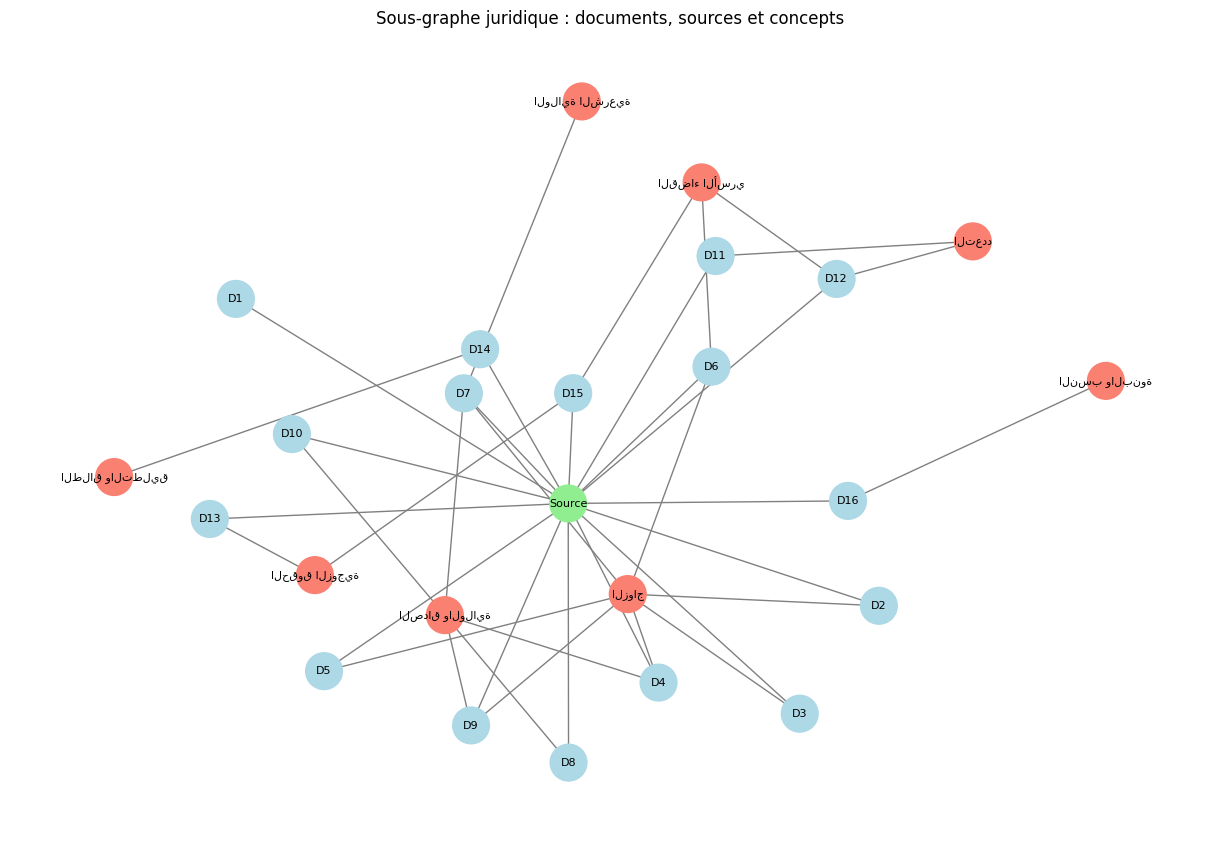

In [12]:
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, seed=42, k=0.8)

node_colors = []
for node in G.nodes:
    t = G.nodes[node].get("node_type")
    if t == "document":
        node_colors.append("lightblue")
    elif t == "source":
        node_colors.append("lightgreen")
    else:
        node_colors.append("salmon")

# Pour éviter une figure trop chargée, on affiche un sous-graphe des 25 premiers noeuds.
sample_nodes = list(G.nodes())[:25]
SG = G.subgraph(sample_nodes)

pos_s = nx.spring_layout(SG, seed=42, k=0.9)
colors_s = []
for node in SG.nodes:
    t = SG.nodes[node].get("node_type")
    colors_s.append("lightblue" if t == "document" else "lightgreen" if t == "source" else "salmon")

nx.draw(SG, pos_s, with_labels=False, node_size=700, node_color=colors_s, edge_color="gray")
labels = {}
for node in SG.nodes:
    if node.startswith("DOC_"):
        labels[node] = node.replace("DOC_", "D")
    elif node.startswith("TOPIC_"):
        labels[node] = node.replace("TOPIC_", "")
    else:
        labels[node] = "Source"
nx.draw_networkx_labels(SG, pos_s, labels=labels, font_size=8)
plt.title("Sous-graphe juridique : documents, sources et concepts")
plt.axis("off")
plt.show()


## 11. Architecture 7 — Agentic RAG

In [13]:
def needs_retrieval(query):
    legal_keywords = [
        "المادة", "القانون", "مدونة الأسرة", "الزواج", "الزوج", "الزوجة",
        "الصداق", "التعدد", "الطلاق", "التطليق", "الشقاق", "الخلع",
        "العدة", "النسب", "البنوة", "الحضانة", "المحضون", "الزيارة",
        "النفقة", "القاصر", "الولاية", "المحكمة", "قاضي الأسرة"
    ]
    return any(k in query for k in legal_keywords)


def agentic_rag(query, max_steps=2):
    logs = []

    if not needs_retrieval(query):
        logs.append("Decision: DIRECT")
        return {
            "answer": generate_answer(query, contexts=None),
            "contexts": [],
            "sources": [],
            "logs": logs
        }

    logs.append("Decision: RETRIEVAL")

    # Step 1: utiliser hybride 
    retrieved = hybrid_retrieve(query, k=3)
    logs.append("Step 1: hybrid retrieval")

    contexts = [r["text"] for r in retrieved]

    # Step 2: vérifier si les termes de la question sont bien couverts
    coverage = keyword_overlap_score(query, " ".join(contexts))
    logs.append(f"Coverage score: {coverage:.2f}")

    if coverage < 0.25 and max_steps > 1:
        second_query = build_second_hop_query(query, contexts)
        more_docs = graph_retrieve(second_query, k=2)
        logs.append(f"Step 2: graph retrieval with query = {second_query}")

        all_docs = {d["id"]: d for d in retrieved + more_docs}
        retrieved = list(all_docs.values())
        contexts = [r["text"] for r in retrieved]

    sources = [f"ID {r['id']} — {r['source']}" for r in retrieved]
    answer = generate_answer(query, contexts)

    return {
        "answer": answer,
        "contexts": contexts,
        "sources": sources,
        "logs": logs
    }


agentic_rag(test_query)


{'answer': 'المادة 1 من مدونة الأسرة المغربية: تسمى الأحكام المتعلقة بالأسرة بمدونة الأسرة، وتهدف إلى تنظيم العلاقات الأسرية بما يضمن المساواة والعدل وحماية حقوق جميع أفراد الأسرة. قرار قضائي أسري: تؤكد المحاكم المغربية في قضايا الحضانة أن مصلحة المحضون هي المعيار الأساسي في إسناد الحضانة أو تعديلها، حتى عند وجود ترتيب قانوني مسبق. المادة 19: تكتمل أهلية الزواج بإتمام الفتى والفتاة ثمان عشرة سنة شمسية، مع التمتع بالأهلية العقلية.\n\nالمصادر المعتمدة مأخوذة من الوثائق المسترجعة.',
 'contexts': ['المادة 1 من مدونة الأسرة المغربية: تسمى الأحكام المتعلقة بالأسرة بمدونة الأسرة، وتهدف إلى تنظيم العلاقات الأسرية بما يضمن المساواة والعدل وحماية حقوق جميع أفراد الأسرة.',
  'قرار قضائي أسري: تؤكد المحاكم المغربية في قضايا الحضانة أن مصلحة المحضون هي المعيار الأساسي في إسناد الحضانة أو تعديلها، حتى عند وجود ترتيب قانوني مسبق.',
  'المادة 19: تكتمل أهلية الزواج بإتمام الفتى والفتاة ثمان عشرة سنة شمسية، مع التمتع بالأهلية العقلية.'],
 'sources': ['ID 1 — مدونة الأسرة المغربية',
  'ID 50 — الاجتهاد 

## 12. Tests réalistes liés au domaine juridique

In [14]:
queries = [
    "ما هي أهلية الزواج حسب مدونة الأسرة المغربية؟",
    "ما هو تعريف الزواج في مدونة الأسرة؟",
    "ما هي حقوق الأطفال على أبويهم؟",
    "متى يمكن للزوجة طلب التطليق؟",
    "ما هي الحضانة ومن له الحق فيها بعد الطلاق؟"
]

golden_references = [
    "تكتمل أهلية الزواج بإتمام الفتى والفتاة ثمان عشرة سنة شمسية مع التمتع بالأهلية العقلية.",
    "الزواج ميثاق تراض وترابط شرعي بين رجل وامرأة على وجه الدوام، غايته الإحصان والعفاف وإنشاء أسرة مستقرة تحت رعاية الزوجين.",
    "للأطفال على أبويهم حقوق، منها حماية حياتهم وصحتهم، تثبيت هويتهم، النسب، الحضانة، النفقة، التعليم، والتوجيه الديني والتربوي السليم.",
    "يمكن للزوجة طلب التطليق لأسباب مثل إخلال الزوج بشرط من شروط عقد الزواج، الضرر، عدم الإنفاق، الغيبة، العيب، أو الإيلاء والهجر.",
    "الحضانة هي حفظ الولد مما قد يضره والقيام بتربيته ومصالحه، وعند انحلال الزواج يعهد بها للأم ثم للأب ثم لأم الأم مع مراعاة مصلحة المحضون."
]

methods = {
    "baseline_no_rag": llm_no_rag,
    "rag_classic": rag_classic,
    "rag_rerank": rag_rerank,
    "rag_hybrid": rag_hybrid,
    "multi_hop": multi_hop_rag,
    "graph_rag": graph_rag,
    "agentic_rag": agentic_rag
}


## 13. Tableau comparatif des réponses

In [15]:
results_rows = []

for q_idx, query in enumerate(queries, start=1):
    print(f"Processing Q{q_idx}/{len(queries)}")
    for method_name, method_func in methods.items():
        try:
            output = method_func(query)
            answer = output.get("answer", "")
            sources = " | ".join(output.get("sources", []))
            contexts = output.get("contexts", [])
        except Exception as e:
            answer = f"ERROR: {e}"
            sources = ""
            contexts = []

        results_rows.append({
            "question_id": f"Q{q_idx}",
            "query": query,
            "method": method_name,
            "answer": answer,
            "sources": sources,
            "num_contexts": len(contexts)
        })

df_results = pd.DataFrame(results_rows)
df_results


Processing Q1/5
Processing Q2/5
Processing Q3/5
Processing Q4/5
Processing Q5/5


,question_id,query,method,answer,sources,num_contexts
0,Q1,ما هي أهلية الزواج حسب مدونة الأسرة المغربية؟,baseline_no_rag,لا أستطيع إعطاء جواب قانوني موثوق بدون الرجوع إلى قاعدة المعرفة القانونية.,,0
1,Q1,ما هي أهلية الزواج حسب مدونة الأسرة المغربية؟,rag_classic,المادة 1 من مدونة الأسرة المغربية: تسمى الأحكام المتعلقة بالأسرة بمدونة الأسرة، وتهدف إلى تنظيم العلاقات الأسرية بما...,ID 1 — مدونة الأسرة المغربية | ID 50 — الاجتهاد القضائي المغربي - قضاء الأسرة | ID 2 — مدونة الأسرة المغربية,3
2,Q1,ما هي أهلية الزواج حسب مدونة الأسرة المغربية؟,rag_rerank,المادة 1 من مدونة الأسرة المغربية: تسمى الأحكام المتعلقة بالأسرة بمدونة الأسرة، وتهدف إلى تنظيم العلاقات الأسرية بما...,ID 1 — مدونة الأسرة المغربية | ID 4 — مدونة الأسرة المغربية | ID 50 — الاجتهاد القضائي المغربي - قضاء الأسرة,3
3,Q1,ما هي أهلية الزواج حسب مدونة الأسرة المغربية؟,rag_hybrid,المادة 1 من مدونة الأسرة المغربية: تسمى الأحكام المتعلقة بالأسرة بمدونة الأسرة، وتهدف إلى تنظيم العلاقات الأسرية بما...,ID 1 — مدونة الأسرة المغربية | ID 50 — الاجتهاد القضائي المغربي - قضاء الأسرة | ID 5 — مدونة الأسرة المغربية,3
4,Q1,ما هي أهلية الزواج حسب مدونة الأسرة المغربية؟,multi_hop,المادة 1 من مدونة الأسرة المغربية: تسمى الأحكام المتعلقة بالأسرة بمدونة الأسرة، وتهدف إلى تنظيم العلاقات الأسرية بما...,ID 1 — مدونة الأسرة المغربية | ID 50 — الاجتهاد القضائي المغربي - قضاء الأسرة | ID 2 — مدونة الأسرة المغربية | ID 5 ...,4
5,Q1,ما هي أهلية الزواج حسب مدونة الأسرة المغربية؟,graph_rag,المادة 19: تكتمل أهلية الزواج بإتمام الفتى والفتاة ثمان عشرة سنة شمسية، مع التمتع بالأهلية العقلية. المادة 13: يشترط...,ID 5 — مدونة الأسرة المغربية | ID 4 — مدونة الأسرة المغربية | ID 2 — مدونة الأسرة المغربية | ID 6 — مدونة الأسرة الم...,4
6,Q1,ما هي أهلية الزواج حسب مدونة الأسرة المغربية؟,agentic_rag,المادة 1 من مدونة الأسرة المغربية: تسمى الأحكام المتعلقة بالأسرة بمدونة الأسرة، وتهدف إلى تنظيم العلاقات الأسرية بما...,ID 1 — مدونة الأسرة المغربية | ID 50 — الاجتهاد القضائي المغربي - قضاء الأسرة | ID 5 — مدونة الأسرة المغربية,3
7,Q2,ما هو تعريف الزواج في مدونة الأسرة؟,baseline_no_rag,لا أستطيع إعطاء جواب قانوني موثوق بدون الرجوع إلى قاعدة المعرفة القانونية.,,0
8,Q2,ما هو تعريف الزواج في مدونة الأسرة؟,rag_classic,المادة 1 من مدونة الأسرة المغربية: تسمى الأحكام المتعلقة بالأسرة بمدونة الأسرة، وتهدف إلى تنظيم العلاقات الأسرية بما...,ID 2 — مدونة الأسرة المغربية | ID 1 — مدونة الأسرة المغربية | ID 3 — مدونة الأسرة المغربية,3
9,Q2,ما هو تعريف الزواج في مدونة الأسرة؟,rag_rerank,المادة 1 من مدونة الأسرة المغربية: تسمى الأحكام المتعلقة بالأسرة بمدونة الأسرة، وتهدف إلى تنظيم العلاقات الأسرية بما...,ID 2 — مدونة الأسرة المغربية | ID 3 — مدونة الأسرة المغربية | ID 1 — مدونة الأسرة المغربية,3


In [16]:

df_answers = df_results.pivot(index="question_id", columns="method", values="answer")
df_answers


method,agentic_rag,baseline_no_rag,graph_rag,multi_hop,rag_classic,rag_hybrid,rag_rerank
question_id,,,,,,,
Q1,المادة 1 من مدونة الأسرة المغربية: تسمى الأحكام المتعلقة بالأسرة بمدونة الأسرة، وتهدف إلى تنظيم العلاقات الأسرية بما...,لا أستطيع إعطاء جواب قانوني موثوق بدون الرجوع إلى قاعدة المعرفة القانونية.,المادة 19: تكتمل أهلية الزواج بإتمام الفتى والفتاة ثمان عشرة سنة شمسية، مع التمتع بالأهلية العقلية. المادة 13: يشترط...,المادة 1 من مدونة الأسرة المغربية: تسمى الأحكام المتعلقة بالأسرة بمدونة الأسرة، وتهدف إلى تنظيم العلاقات الأسرية بما...,المادة 1 من مدونة الأسرة المغربية: تسمى الأحكام المتعلقة بالأسرة بمدونة الأسرة، وتهدف إلى تنظيم العلاقات الأسرية بما...,المادة 1 من مدونة الأسرة المغربية: تسمى الأحكام المتعلقة بالأسرة بمدونة الأسرة، وتهدف إلى تنظيم العلاقات الأسرية بما...,المادة 1 من مدونة الأسرة المغربية: تسمى الأحكام المتعلقة بالأسرة بمدونة الأسرة، وتهدف إلى تنظيم العلاقات الأسرية بما...
Q2,المادة 400: كل ما لم يرد به نص في مدونة الأسرة يرجع فيه إلى المذهب المالكي والاجتهاد الذي يراعي قيم العدل والمساواة ...,لا أستطيع إعطاء جواب قانوني موثوق بدون الرجوع إلى قاعدة المعرفة القانونية.,المادة 4: الزواج ميثاق تراض وترابط شرعي بين رجل وامرأة على وجه الدوام، غايته الإحصان والعفاف وإنشاء أسرة مستقرة تحت ...,المادة 400: كل ما لم يرد به نص في مدونة الأسرة يرجع فيه إلى المذهب المالكي والاجتهاد الذي يراعي قيم العدل والمساواة ...,المادة 1 من مدونة الأسرة المغربية: تسمى الأحكام المتعلقة بالأسرة بمدونة الأسرة، وتهدف إلى تنظيم العلاقات الأسرية بما...,المادة 400: كل ما لم يرد به نص في مدونة الأسرة يرجع فيه إلى المذهب المالكي والاجتهاد الذي يراعي قيم العدل والمساواة ...,المادة 1 من مدونة الأسرة المغربية: تسمى الأحكام المتعلقة بالأسرة بمدونة الأسرة، وتهدف إلى تنظيم العلاقات الأسرية بما...
Q3,لا أستطيع إعطاء جواب قانوني موثوق بدون الرجوع إلى قاعدة المعرفة القانونية.,لا أستطيع إعطاء جواب قانوني موثوق بدون الرجوع إلى قاعدة المعرفة القانونية.,المادة 54: للأطفال على أبويهم حقوق، منها حماية حياتهم وصحتهم، تثبيت هويتهم، النسب، الحضانة، النفقة، التعليم، والتوجي...,المادة 54: للأطفال على أبويهم حقوق، منها حماية حياتهم وصحتهم، تثبيت هويتهم، النسب، الحضانة، النفقة، التعليم، والتوجي...,المادة 54: للأطفال على أبويهم حقوق، منها حماية حياتهم وصحتهم، تثبيت هويتهم، النسب، الحضانة، النفقة، التعليم، والتوجي...,المادة 54: للأطفال على أبويهم حقوق، منها حماية حياتهم وصحتهم، تثبيت هويتهم، النسب، الحضانة، النفقة، التعليم، والتوجي...,المادة 54: للأطفال على أبويهم حقوق، منها حماية حياتهم وصحتهم، تثبيت هويتهم، النسب، الحضانة، النفقة، التعليم، والتوجي...
Q4,المادة 104: إذا غاب الزوج عن زوجته مدة تزيد عن سنة، أمكن للزوجة طلب التطليق للغيبة إذا تضررت من ذلك. المادة 102: للز...,لا أستطيع إعطاء جواب قانوني موثوق بدون الرجوع إلى قاعدة المعرفة القانونية.,المادة 104: إذا غاب الزوج عن زوجته مدة تزيد عن سنة، أمكن للزوجة طلب التطليق للغيبة إذا تضررت من ذلك. المادة 102: للز...,المادة 104: إذا غاب الزوج عن زوجته مدة تزيد عن سنة، أمكن للزوجة طلب التطليق للغيبة إذا تضررت من ذلك. المادة 98: للزو...,المادة 104: إذا غاب الزوج عن زوجته مدة تزيد عن سنة، أمكن للزوجة طلب التطليق للغيبة إذا تضررت من ذلك. المادة 98: للزو...,المادة 104: إذا غاب الزوج عن زوجته مدة تزيد عن سنة، أمكن للزوجة طلب التطليق للغيبة إذا تضررت من ذلك. المادة 102: للز...,المادة 104: إذا غاب الزوج عن زوجته مدة تزيد عن سنة، أمكن للزوجة طلب التطليق للغيبة إذا تضررت من ذلك. المادة 102: للز...
Q5,قرار قضائي أسري: تؤكد المحاكم المغربية في قضايا الحضانة أن مصلحة المحضون هي المعيار الأساسي في إسناد الحضانة أو تعدي...,لا أستطيع إعطاء جواب قانوني موثوق بدون الرجوع إلى قاعدة المعرفة القانونية.,المادة 163: الحضانة حفظ الولد مما قد يضره، والقيام بتربيته ومصالحه، وهي واجبة على الأبوين ما دامت علاقة الزوجية قائم...,قرار قضائي أسري: تؤكد المحاكم المغربية في قضايا الحضانة أن مصلحة المحضون هي المعيار الأساسي في إسناد الحضانة أو تعدي...,المادة 79: يجب على من يريد الطلاق أن يطلب الإذن من المحكمة بالإشهاد به لدى عدلين منتصبين لذلك، بدائرة نفوذ المحكمة ا...,قرار قضائي أسري: تؤكد المحاكم المغربية في قضايا الحضانة أن مصلحة المحضون هي المعيار الأساسي في إسناد الحضانة أو تعدي...,المادة 78: الطلاق حل ميثاق الزوجية يمارسه الزوج والزوجة، كل بحسب شر

## 14. Métriques d'évaluation

In [17]:
def semantic_similarity(a, b):
    vecs = embedding_model.encode([a, b], convert_to_numpy=True, normalize_embeddings=True)
    return float(cosine_similarity([vecs[0]], [vecs[1]])[0][0])

def faithfulness_proxy(answer, contexts):
    # Proxy simple : proportion des mots de la réponse présents dans le contexte
    if not contexts or not answer:
        return 0.0

    answer_words = set(re.findall(r"\w+", normalize_arabic(answer)))
    context_words = set(re.findall(r"\w+", normalize_arabic(" ".join(contexts))))

    if not answer_words:
        return 0.0

    return len(answer_words.intersection(context_words)) / len(answer_words)


def retrieval_hit(query, contexts, reference):
    # Hit si au moins un contexte est proche de la référence
    if not contexts:
        return 0.0

    scores = [semantic_similarity(ctx, reference) for ctx in contexts]
    return 1.0 if max(scores) >= 0.45 else 0.0


def context_relevance(query, contexts):
    if not contexts:
        return 0.0

    scores = [semantic_similarity(query, ctx) for ctx in contexts]
    return float(np.mean(scores))


def judge_legal_accuracy(query, answer, reference):
    """
    Évalue si la réponse générée est juridiquement correcte
    en la comparant à la réponse de référence.

    Score entre 0 et 1 :
    - proche de 1 : réponse juridiquement correcte
    - proche de 0 : réponse faible ou incorrecte
    """
    if not answer or not reference:
        return 0.0

    sim = semantic_similarity(answer, reference)

    # Bonus si la réponse contient des termes juridiques importants du droit de la famille
    legal_keywords = [
        "المادة", "القانون", "مدونة الأسرة", "الزواج", "الزوج", "الزوجة",
        "الصداق", "التعدد", "الطلاق", "التطليق", "الشقاق", "الخلع",
        "العدة", "النسب", "البنوة", "الحضانة", "المحضون", "الزيارة",
        "النفقة", "القاصر", "الولاية", "المحكمة", "قاضي الأسرة"
    ]

    answer_norm = normalize_arabic(answer)
    keyword_hits = sum(1 for kw in legal_keywords if normalize_arabic(kw) in answer_norm)
    keyword_score = min(keyword_hits / 3, 1.0)

    # Score final : similarité avec la référence + présence du vocabulaire juridique
    legal_score = (0.8 * sim) + (0.2 * keyword_score)

    return float(legal_score)


metric_rows = []

for q_idx, query in enumerate(queries, start=1):
    reference = golden_references[q_idx - 1]

    for method_name, method_func in methods.items():
        output = method_func(query)
        answer = output.get("answer", "")
        contexts = output.get("contexts", [])

        sim = semantic_similarity(answer, reference) if answer else 0.0
        faith = faithfulness_proxy(answer, contexts)
        rel = context_relevance(query, contexts)
        hit = retrieval_hit(query, contexts, reference)
        legal_acc = judge_legal_accuracy(query, answer, reference)

        metric_rows.append({
            "question_id": f"Q{q_idx}",
            "method": method_name,
            "answer_reference_similarity": sim,
            "context_relevance": rel,
            "retrieval_hit": hit,
            "faithfulness_proxy": faith,
            "legal_accuracy": legal_acc
        })

df_metrics = pd.DataFrame(metric_rows)
df_metrics.head()


,question_id,method,answer_reference_similarity,context_relevance,retrieval_hit,faithfulness_proxy,legal_accuracy
0,Q1,baseline_no_rag,0.037613,0.000000,0.0,0.000000,0.096757
1,Q1,rag_classic,0.423206,0.645175,1.0,0.931507,0.538565
2,Q1,rag_rerank,0.344164,0.611342,0.0,0.934211,0.475331
3,Q1,rag_hybrid,0.488031,0.598013,1.0,0.925373,0.590425
4,Q1,multi_hop,0.488031,0.597033,1.0,0.925373,0.590425


In [18]:
summary_metrics = (
    df_metrics
    .groupby("method")
    .agg({
        "answer_reference_similarity": "mean",
        "context_relevance": "mean",
        "retrieval_hit": "mean",
        "faithfulness_proxy": "mean",
        "legal_accuracy": "mean"
    })
    .sort_values("answer_reference_similarity", ascending=False)
)

summary_metrics


,answer_reference_similarity,context_relevance,retrieval_hit,faithfulness_proxy,legal_accuracy
method,,,,,
graph_rag,0.734557,0.573175,1.0,0.910920,0.787645
rag_hybrid,0.609606,0.647213,1.0,0.916320,0.687685
multi_hop,0.604012,0.641526,1.0,0.912260,0.683209
rag_classic,0.602814,0.678961,1.0,0.909987,0.682251
rag_rerank,0.595797,0.656038,0.8,0.906031,0.676637
agentic_rag,0.499763,0.500308,0.8,0.735675,0.573144
baseline_no_rag,0.125464,0.000000,0.0,0.000000,0.167038


Nous avons retenu cinq métriques essentielles pour comparer les architectures RAG.  
La métrique `answer_reference_similarity` mesure la proximité entre la réponse générée et la réponse de référence.  
La métrique `context_relevance` évalue la pertinence des documents récupérés par rapport à la question.  
La métrique `retrieval_hit` indique si au moins un document pertinent a été retrouvé.  
La métrique `faithfulness_proxy` estime la fidélité de la réponse générée aux documents utilisés comme contexte.  
Enfin, la métrique `legal_accuracy` évalue si la réponse générée respecte le sens juridique attendu, en tenant compte de sa similarité avec la référence et de la présence de termes juridiques importants.

Le tableau présente la moyenne de ces métriques pour chaque architecture, ce qui permet de comparer globalement les performances des différentes méthodes RAG dans le contexte d’un assistant juridique en arabe.

## 15. Visualisation des métriques

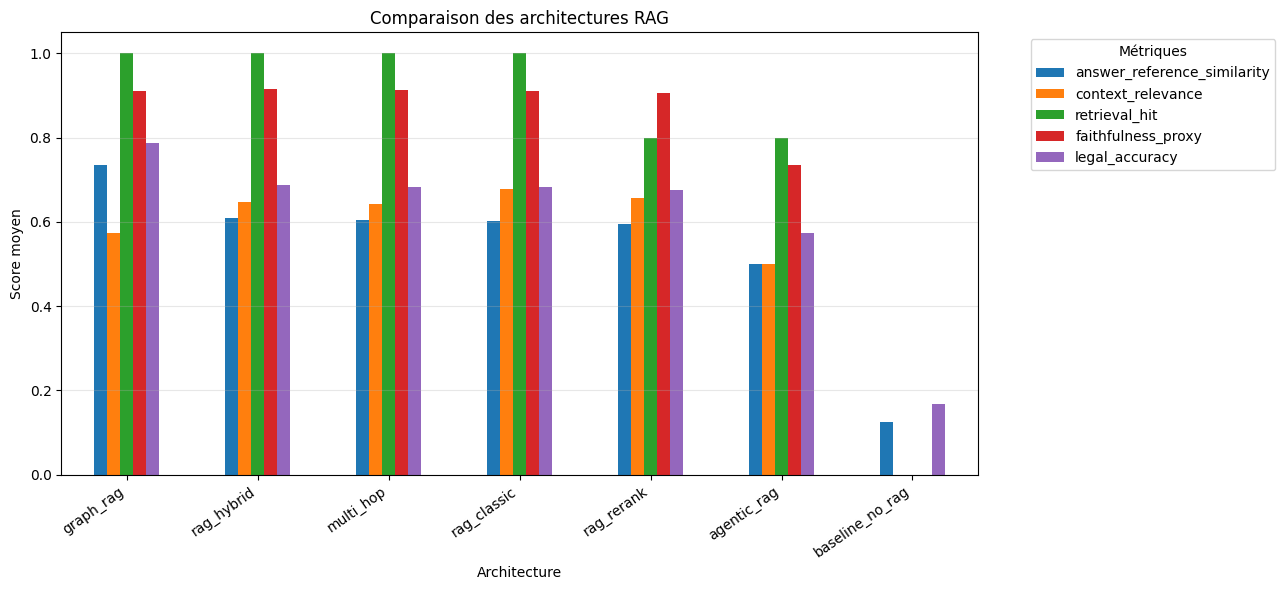

In [19]:
summary_metrics[
    [
        "answer_reference_similarity",
        "context_relevance",
        "retrieval_hit",
        "faithfulness_proxy",
        "legal_accuracy"
    ]
].plot(kind="bar", figsize=(13, 6))

plt.title("Comparaison des architectures RAG")
plt.ylabel("Score moyen")
plt.xlabel("Architecture")
plt.xticks(rotation=35, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.legend(title="Métriques", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


## 16. Visualisation t-SNE des embeddings

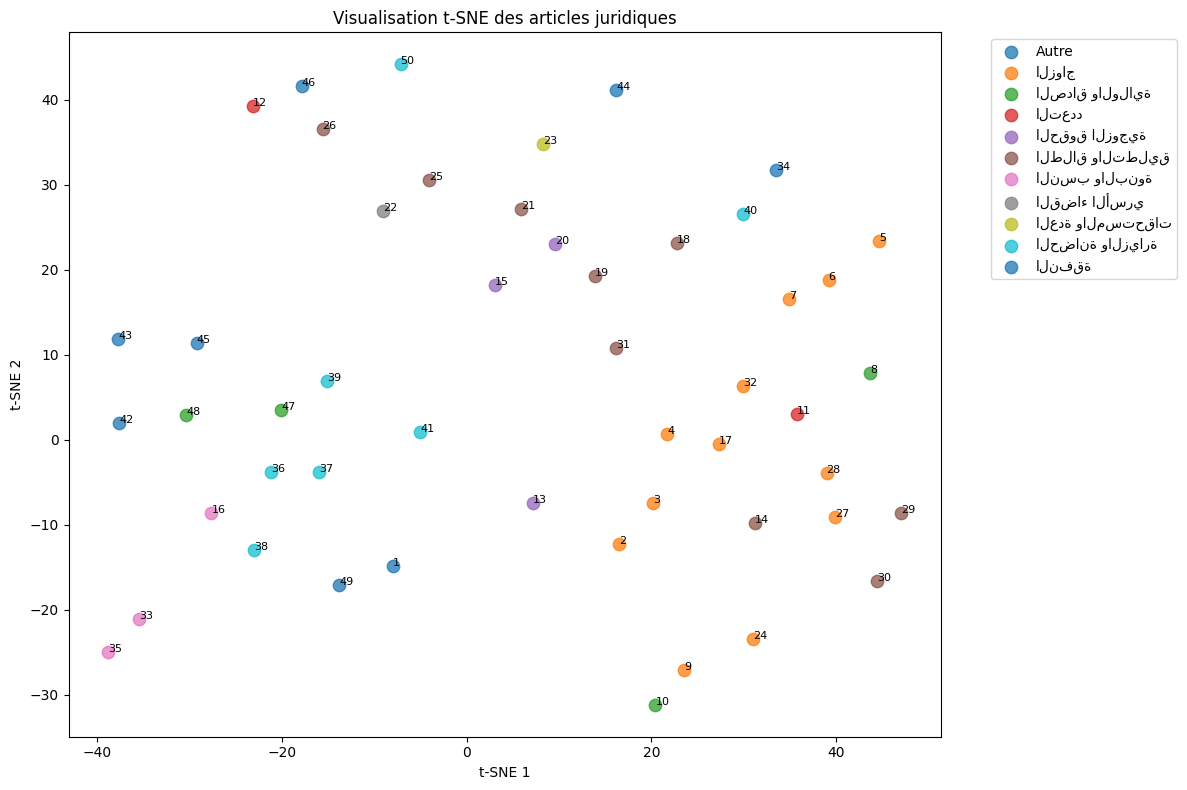

In [20]:
perplexity = min(10, max(2, len(documents) // 5))

tsne = TSNE(
    n_components=2,
    perplexity=perplexity,
    random_state=42,
    init="random",
    learning_rate="auto"
)

emb_2d = tsne.fit_transform(doc_embeddings)

df_viz = df_docs.copy()
df_viz["x"] = emb_2d[:, 0]
df_viz["y"] = emb_2d[:, 1]
df_viz["topic"] = df_viz["text"].apply(lambda t: detect_topics(t)[0] if detect_topics(t) else "Autre")

plt.figure(figsize=(12, 8))
for topic in df_viz["topic"].unique():
    subset = df_viz[df_viz["topic"] == topic]
    plt.scatter(subset["x"], subset["y"], label=topic, s=80, alpha=0.75)

for _, row in df_viz.iterrows():
    plt.text(row["x"], row["y"], str(row["id"]), fontsize=8)

plt.title("Visualisation t-SNE des articles juridiques")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


La figure présente une visualisation t-SNE des embeddings des articles juridiques du dataset. 
Chaque point représente un document juridique, identifié par son ID. 
Les documents proches dans l’espace 2D ont des représentations sémantiques similaires, ce qui signifie qu’ils traitent probablement de thèmes juridiques proches. 
Cette visualisation permet donc d’observer la structure du corpus et de vérifier si les embeddings utilisés pour le retrieval capturent correctement les relations entre les articles.

## 17. Interface Gradio

In [21]:

def gradio_answer(question, architecture):
    func = methods[architecture]
    output = func(question)
    answer = output.get("answer", "")
    sources = "".join(output.get("sources", []))
    return answer, sources


try:
    import gradio as gr

    demo = gr.Interface(
        fn=gradio_answer,
        inputs=[
            gr.Textbox(label="Question juridique en arabe", value="ما هي أهلية الزواج حسب مدونة الأسرة المغربية؟"),
            gr.Dropdown(choices=list(methods.keys()), value="rag_hybrid", label="Architecture")
        ],
        outputs=[
            gr.Textbox(label="Réponse"),
            gr.Textbox(label="Sources utilisées")
        ],
        title="Assistant juridique RAG — Droit de la famille marocain",
        description="Comparaison des architectures RAG sur un dataset juridique arabe lié à la مدونة الأسرة المغربية."
    )

    print("Gradio interface ready. Run: demo.launch(share=True)")
    demo.launch(share=True)
except Exception as e:
    print("Gradio unavailable:", e)


Gradio interface ready. Run: demo.launch(share=True)
* Running on local URL:  http://127.0.0.1:7862
* Running on public URL: https://8ee6ed9f480c40d40a.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 18. Analyse critique finale

### Quelle architecture est la plus performante ?
La meilleure architecture est celle qui obtient le plus haut score moyen `answer_reference_similarity`, tout en gardant un bon score de `faithfulness_proxy`. Dans le domaine du droit de la famille, la précision et l'ancrage dans les textes de la مدونة الأسرة sont plus importants qu'une réponse longue.

### Quelle architecture est la plus robuste ?
Le **RAG hybride** est généralement le plus robuste, car il combine :
- la recherche dense sémantique ;
- la recherche sparse TF-IDF basée sur les mots clés juridiques ;
- une fusion des scores.

Cela est utile pour l'arabe juridique, car certaines questions utilisent exactement les mots des articles, tandis que d'autres sont reformulées.

### Quelle architecture est la plus adaptée au projet ?
Pour un assistant juridique marocain spécialisé en droit de la famille, les architectures les plus adaptées sont :
- **RAG hybride** : meilleur équilibre précision/simplicité ;
- **Graph RAG** : intéressant pour relier les notions juridiques comme الزواج، الطلاق، الحضانة، النفقة، النسب والولاية الشرعية ;
- **Agentic RAG** : utile lorsqu'une question nécessite plusieurs étapes de recherche.

### Quelle architecture produit le plus d'hallucinations ?
Le **LLM sans RAG** est le plus risqué, car il répond sans consulter le corpus. Dans le domaine juridique, cela peut produire des réponses non vérifiables. Les architectures RAG réduisent ce risque car elles utilisent les articles du dataset comme contexte.

### Conclusion
Le projet démontre que les architectures RAG sont adaptées à un assistant juridique arabe spécialisé en droit de la famille marocain. Le **RAG hybride** est recommandé comme solution principale, avec **Graph RAG** comme extension pour mieux exploiter les relations entre concepts juridiques de la مدونة الأسرة.


## 19. Export des résultats

In [22]:
df_results.to_csv("rag_legal_answers.csv", index=False, encoding="utf-8-sig")
summary_metrics.to_csv("rag_legal_metrics_summary.csv", encoding="utf-8-sig")

print("Files exported:")
print("- rag_legal_answers.csv")
print("- rag_legal_metrics_summary.csv")


Files exported:
- rag_legal_answers.csv
- rag_legal_metrics_summary.csv
